<a href="https://colab.research.google.com/github/ravichas/bifx-546/blob/main/Notebooks/Chapter20_Clustering_Intro_Python_ver2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering — Introduction to Unsupervised Learning

**Course:** BIFX-546 — Machine Learning for Bioinformatics  
**Instructor:** Dr. Sarangan Ravichandran (Ravi)  
**Platform:** Google Colab  

---

> **Attribution:** This notebook is adapted from the R-based tutorial *Clustering and Heatmaps* (part of the *Data Analysis for the Life Sciences* series). The original R code used the `tissuesGeneExpression` Bioconductor package. Here, we recreate an equivalent synthetic gene expression dataset in Python so all concepts and visualizations transfer faithfully.

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. Explain what unsupervised clustering is and why it is useful in genomics
2. Define distance measures, compute pairwise Euclidean distances between samples,
   and explain when alternative distances (correlation, cosine, Manhattan) are more appropriate
3. Perform hierarchical clustering and interpret dendrograms
4. Cut a dendrogram at a chosen height (or number of clusters) and evaluate cluster quality
5. Perform k-means clustering and understand the effect of feature selection
6. Visualize high-dimensional data in 2D using MDS (Multidimensional Scaling)
7. Build annotated heatmaps with hierarchical dendrograms using `seaborn`

---

## 1. Background — Basic Machine Learning

Machine learning is a very broad topic and a highly active research area. In the life sciences, much of what is described as **precision medicine** is an application of machine learning to biomedical data. The general idea is to **predict or discover outcomes** from measured predictors.

Two motivating questions in bioinformatics:
- Can we **discover new types of cancer** from gene expression profiles?
- Can we **predict drug response** from a series of genotypes?

This notebook covers **clustering** — a form of *unsupervised* learning in which we try to find structure in data without pre-defined labels.

> 📖 **Recommended reading:** *The Elements of Statistical Learning* by Hastie, Tibshirani & Friedman (free PDF at [statweb.stanford.edu](https://statweb.stanford.edu/~tibs/ElemStatLearn/))

## Applications
* Useful when labeled data is unavailable
* Discovers hidden patterns and relationships
* Idetifies anomalies/fraud signals
* Helps create customer segmentation and personalization

Note: Results require domain expertise for interpretation.

## Key tasks in unsupervised learning
* Clustering
* Pattern and relationship discovery in unlabeled data
* Dimensionality reduction (PCA)

## Clustering Methods
### K-Means:
  * Randomly initialize cluster placement
  * Assign data points to the nearest centroid
  * update centroids to the mean of assigned points
  * iterate until convergence
  * Note: Method assume spherically, equally sized clusters; requires, predefined cluster count or K and assumes the data is properly scaled

### Hierarchical Clustering
  * Constructs cluster through stepwise merging
  * Visualize relationships using dendrograms
  * Uses distance linkages to identify proximity
  * Note: No need to choose predefined cluster count (or K); Method is associated with high cost; early errors can propagate with no option to reverse

## Other methods
  * Density-based Clustering (groups points within dense regions)
    * Groups data into three buckets: Core, border or noise
    * Parameters: epsilon and min-sample  
  * Probability-based approaches
  * Model-based approaches



## 📐 Distance Measures in Clustering

Before diving into any clustering algorithm, we need to answer a fundamental
question: **what does it mean for two data points to be "close" or "far apart"?**

Every clustering algorithm — K-Means, hierarchical, DBSCAN — depends entirely
on a distance measure. Change the distance, and you change the clusters.

---

### The General Idea

A distance measure $d(\mathbf{x}, \mathbf{y})$ takes two data points and returns
a single number that quantifies their dissimilarity.  

A good distance measure satisfies four properties:

- **Non-negativity:** $d(\mathbf{x}, \mathbf{y}) \geq 0$ — distances are never negative
- **Identity:** $d(\mathbf{x}, \mathbf{x}) = 0$ — a point has zero distance to itself
- **Symmetry:** $d(\mathbf{x}, \mathbf{y}) = d(\mathbf{y}, \mathbf{x})$ — distance is the same in both directions
- **Triangle inequality:** $d(\mathbf{x}, \mathbf{z}) \leq d(\mathbf{x}, \mathbf{y}) + d(\mathbf{y}, \mathbf{z})$ —
the direct distance between two points can never be longer than the path
through a third point. Think of three cities A, B, C on a map: flying
directly from A to C is always at most as far as flying A → B → C.
**This property holds in any number of dimensions — whether your data points
are locations in 2D space, gene expression profiles in 500D space, or
protein sequences.** The geometry of "going through a detour is never shorter
than going direct" is a universal truth regardless of dimensionality.

---

### Euclidean Distance — The Default

The most common choice is **Euclidean distance** — the straight-line distance
between two points in $d$-dimensional space:

$$d_{\text{Euclidean}}({x}, {y}) =
\left( \sum_{i=1}^{d} (x_i - y_i)^2 \right)^{1/2}$$

**In 2D** (e.g., two users on a city map):

$$d\bigl([-14, -5],\ [13, 13]\bigr) = \left((-14-13)^2 + (-5-13)^2\right)^{1/2}
= (729 + 324)^{1/2} \approx 32.4$$

**In genomics** (e.g., two samples each with 500 gene expression values):
the same formula applies, just summing over 500 dimensions instead of 2.

Euclidean distance works well when:
- All features are on the **same scale** (or have been standardized)
- The data lives in roughly **spherical** cluster structures — meaning points
  spread out roughly equally in all directions from the cluster center.
  In 2D this looks like a circle, in 3D a ball, and in higher dimensions
  a hypersphere — but the idea is the same regardless of dimensionality:
  no single direction dominates the spread of the cluster
- Features are **continuous and numeric**

---

### Other Distance Measures

Euclidean distance is not always the right choice. Here are the most common
alternatives and when to use them:

| Distance | Formula | Best used when |
|----------|---------|----------------|
| **Manhattan** | $\sum_i \|x_i - y_i\|$ | Features have outliers; city-block movement |
| **Cosine** | $1 - \dfrac{\mathbf{x} \cdot \mathbf{y}}{\|\mathbf{x}\|\|\mathbf{y}\|}$ | Direction matters more than magnitude (text, RNA-seq counts) |
| **Correlation** | $1 - \text{Pearson}(\mathbf{x}, \mathbf{y})$ | Expression *patterns* matter, not absolute levels |
| **Hamming** | Fraction of positions that differ | Categorical data, DNA sequences |
| **Jaccard** | $1 - \dfrac{|A \cap B|}{|A \cup B|}$ | Binary or set-valued data |

---

### Which Distance to Use in Bioinformatics?

| Data type | Recommended distance | Reason |
|-----------|---------------------|--------|
| Normalized gene expression (microarray) | Euclidean or Correlation | Samples comparable after normalization |
| Raw RNA-seq counts | Correlation or Cosine | Count magnitudes vary by sequencing depth |
| DNA/protein sequences | Hamming or edit distance | Sequences are categorical, not numeric |
| Binary presence/absence data | Jaccard | Set overlap is more meaningful than magnitude |

> 💡 **Rule of thumb:** If you have normalized, continuous numeric data —
> start with Euclidean. If expression *patterns* matter more than absolute
> levels (e.g., one sample was sequenced more deeply than another), use
> Correlation distance instead.

---

### A Note on Scaling

Euclidean distance is **sensitive to the scale of each feature**. A gene
with expression values in the range [0, 1000] will dominate the distance
calculation over a gene in the range [0, 1], even if the second gene is
biologically more informative.

**Always standardize your features before clustering with Euclidean distance:**

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

In the code below, `StandardScaler()` handles this automatically.

## 📌 K-Means Clustering: Core Concepts (IBM Think Reference)

**Source:** [IBM Think — What is K-Means Clustering?](https://www.ibm.com/think/topics/k-means-clustering)

---

### What is K-Means?

K-Means is an **unsupervised, centroid-based clustering algorithm** that partitions a dataset
into *k* groups by minimizing the total distance between data points and their assigned cluster center.
It is an example of **exclusive ("hard") clustering** — each point belongs to exactly one cluster.

---

### The Algorithm (Step-by-Step)

| Step | What Happens |
|------|-------------|
| 1. **Initialize** | Choose *k* centroids (randomly or via k-means++) |
| 2. **Assign (E-step)** | Assign each point to its nearest centroid (Euclidean distance) |
| 3. **Update (M-step)** | Recompute each centroid as the mean of its assigned points |
| 4. **Repeat** | Repeat steps 2–3 until centroids stop moving (convergence) |

This two-step loop is an instance of the **Expectation-Maximization (EM)** framework.

---

### Cluster Quality Metrics

**Inertia (Within-Cluster Sum of Squares, WCSS)**

$$\text{Inertia} = \sum_{j=1}^{k} \sum_{x_i \in C_j} \|x_i - \mu_j\|^2$$

Where:
- $k$ — number of clusters
- $C_j$ — the set of all points assigned to cluster $j$
- $x_i$ — a single data point inside cluster $j$
- $\mu_j$ — the centroid (mean) of cluster $j$
- $\|x_i - \mu_j\|^2$ — squared Euclidean distance from point $x_i$ to its own cluster center

**How to read it:** For each cluster $j$, sum the squared distances of every point in that cluster to cluster $j$'s centroid. Then add those sums across all $k$ clusters.

Lower inertia → more compact clusters. **K-Means minimizes this objective.**


**Dunn Index**
Measures the ratio of *minimum intercluster distance* to *maximum intracluster distance*.
Higher Dunn index → clusters are well-separated and compact.

---

### Choosing Optimal *k*: The Elbow Method

Plot WCSS vs. *k*. The "elbow" — where the rate of decrease sharply levels off — is the
recommended number of clusters. Beyond the elbow, adding more clusters yields diminishing returns (i.e., where the curve transitions from steep to shallow)

---

### K-Means++ Initialization

Standard random initialization can yield poor clusters. **K-Means++** (Arthur & Vassilvitskii)
spreads initial centroids farther apart, leading to:
- Faster convergence
- Higher-quality cluster assignments

`sklearn` uses k-means++ by default (`init='k-means++'`).

---

### Advantages & Limitations

| ✅ Advantages | ⚠️ Limitations |
|--------------|----------------|
| Simple and fast | Sensitive to initial centroid placement |
| Scales to large datasets | Requires *k* to be specified upfront |
| Intuitive interpretation | Struggles with outliers and unequal cluster sizes |
| Works well with compact, spherical clusters | Poor on high-dimensional or irregularly shaped data |

---

### Real-World Applications

- **Customer segmentation** — group customers by purchasing behavior
- **Document clustering** — organize text by topic
- **Image segmentation** — partition pixels into regions
- **Recommendation engines** — cluster users or products by similarity

## Functions used in this following code chunk

### `make_blobs`
`make_blobs` is a scikit-learn utility that generates synthetic clustered data for testing and teaching machine learning algorithms.
It works by placing kk
k cluster centers randomly in space, then scattering points around each center using a Gaussian distribution. You control:


- n_samples — total number of points to generate
centers — number of clusters (or their exact coordinates)
- cluster_std — how tightly packed each cluster is (small = tight, large = spread out)
- random_state — fixes the random seed for reproducibility

```python
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)
```

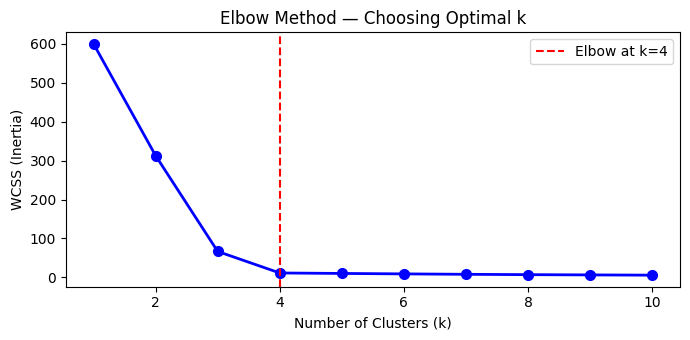

WCSS values: [600.0, 312.73, 66.7, 11.32, 10.13, 9.0, 7.89, 7.03, 6.36, 5.72]


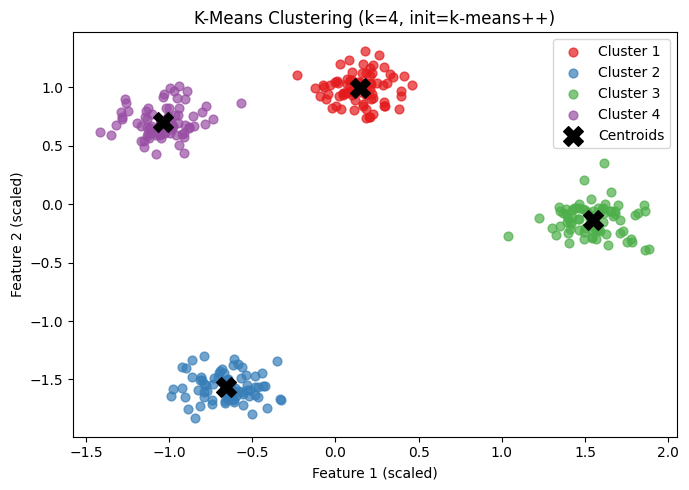

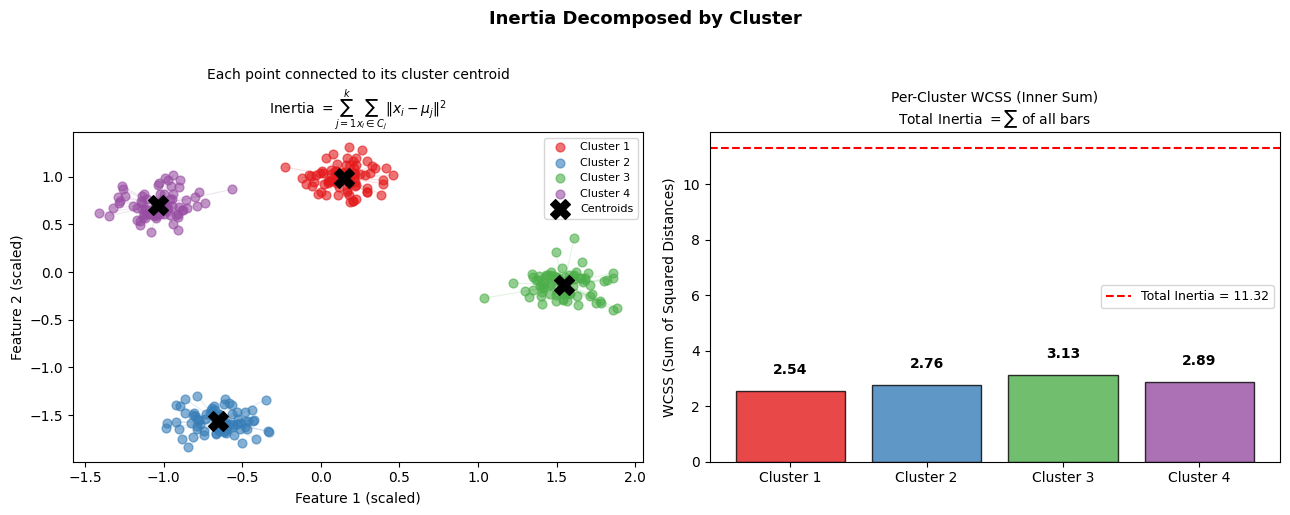


  Inertia = Σ (over clusters) Σ (over points in cluster) ||x_i - μ_j||²
  Cluster 1:  75 points | Centroid ≈ (+0.15, +0.99) | WCSS = 2.54
  Cluster 2:  75 points | Centroid ≈ (-0.66, -1.56) | WCSS = 2.76
  Cluster 3:  75 points | Centroid ≈ (+1.55, -0.13) | WCSS = 3.13
  Cluster 4:  75 points | Centroid ≈ (-1.04, +0.70) | WCSS = 2.89
──────────────────────────────────────────────────
  Total Inertia (sum of all clusters) = 11.32
  sklearn's kmeans.inertia_           = 11.32  ✓


In [ ]:
# @title
# ============================================================
# K-Means Clustering Demo
# Based on: IBM Think — "What is K-Means Clustering?"
# https://www.ibm.com/think/topics/k-means-clustering
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# ── 1. Generate synthetic data ──────────────────────────────
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)
X = StandardScaler().fit_transform(X)   # always scale before K-Means

# ── 2. Elbow Method: find optimal k ─────────────────────────
wcss = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)

plt.figure(figsize=(7, 3.5))
plt.plot(k_range, wcss, 'bo-', linewidth=2, markersize=7)
plt.axvline(x=4, color='red', linestyle='--', label='Elbow at k=4')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method — Choosing Optimal k')
plt.legend(); plt.tight_layout(); plt.show()
print(f"WCSS values: {[round(w, 2) for w in wcss]}")

# ── 3. Fit K-Means with optimal k=4 ─────────────────────────
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10,
                max_iter=300, random_state=42)
labels = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

# ── 4. Visualize clusters ────────────────────────────────────
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
plt.figure(figsize=(7, 5))
for c in range(4):
    mask = labels == c
    plt.scatter(X[mask, 0], X[mask, 1], s=40, color=colors[c],
                alpha=0.7, label=f'Cluster {c+1}')
plt.scatter(centroids[:, 0], centroids[:, 1],
            s=200, c='black', marker='X', zorder=5, label='Centroids')
plt.title('K-Means Clustering (k=4, init=k-means++)')
plt.xlabel('Feature 1 (scaled)'); plt.ylabel('Feature 2 (scaled)')
plt.legend(); plt.tight_layout(); plt.show()

# ── 5. Report cluster metrics ────────────────────────────────
# ── 5. Visualize Inertia Formula — Cluster-by-Cluster ────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left panel: cluster scatter with distance lines ──────────
ax = axes[0]
for c in range(4):
    mask = labels == c
    ax.scatter(X[mask, 0], X[mask, 1], s=40, color=colors[c],
               alpha=0.6, label=f'Cluster {c+1}')
    # Draw a line from each point to its centroid
    for point in X[mask]:
        ax.plot([point[0], centroids[c, 0]],
                [point[1], centroids[c, 1]],
                color=colors[c], alpha=0.15, linewidth=0.8)

ax.scatter(centroids[:, 0], centroids[:, 1],
           s=200, c='black', marker='X', zorder=5, label='Centroids')
ax.set_title('Each point connected to its cluster centroid\n'
             r'Inertia $= \sum_{j=1}^{k} \sum_{x_i \in C_j} \|x_i - \mu_j\|^2$',
             fontsize=10)
ax.set_xlabel('Feature 1 (scaled)')
ax.set_ylabel('Feature 2 (scaled)')
ax.legend(fontsize=8)

# ── Right panel: per-cluster WCSS breakdown bar chart ────────
ax2 = axes[1]
cluster_wcss = []
for c in range(4):
    mask = labels == c
    wcss_c = np.sum(np.linalg.norm(X[mask] - centroids[c], axis=1) ** 2)
    cluster_wcss.append(wcss_c)

bars = ax2.bar([f'Cluster {c+1}' for c in range(4)],
               cluster_wcss, color=colors, edgecolor='black', alpha=0.8)

# Annotate each bar with its WCSS value
for bar, val in zip(bars, cluster_wcss):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.axhline(y=sum(cluster_wcss), color='red', linestyle='--', linewidth=1.5,
            label=f'Total Inertia = {sum(cluster_wcss):.2f}')
ax2.set_title('Per-Cluster WCSS (Inner Sum)\n'
              r'Total Inertia $= \sum$ of all bars', fontsize=10)
ax2.set_ylabel('WCSS (Sum of Squared Distances)')
ax2.legend(fontsize=9)

plt.suptitle('Inertia Decomposed by Cluster', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Printed breakdown ─────────────────────────────────────────
print(f"\n{'='*50}")
print(f"  Inertia = Σ (over clusters) Σ (over points in cluster) ||x_i - μ_j||²")
print(f"{'='*50}")
for c in range(4):
    mask = labels == c
    n_c = np.sum(mask)
    wcss_c = cluster_wcss[c]
    print(f"  Cluster {c+1}: {n_c:>3d} points | "
          f"Centroid ≈ ({centroids[c,0]:+.2f}, {centroids[c,1]:+.2f}) | "
          f"WCSS = {wcss_c:.2f}")
print(f"{'─'*50}")
print(f"  Total Inertia (sum of all clusters) = {sum(cluster_wcss):.2f}")
print(f"  sklearn's kmeans.inertia_           = {kmeans.inertia_:.2f}  ✓")
print(f"{'='*50}")

---

## 2. Setup — Install and Import Libraries

In [ ]:
# @title
# ── Standard imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import KMeans
from sklearn.manifold import MDS

import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully ✓")

All libraries loaded successfully ✓


---

## 3. Synthetic Gene Expression Dataset

The original R notebook used the `tissuesGeneExpression` Bioconductor dataset — a matrix of ~22,000 genes × 189 human tissue samples covering 7 tissue types: cerebellum, colon, endometrium, hippocampus, kidney, liver, and placenta.

We recreate an equivalent **synthetic dataset** that preserves the same key properties:
- 7 tissue types, 189 samples total
- 500 genes (we use a reduced gene set for speed)
- Each tissue type has a characteristic expression signature

The matrix shape follows the bioinformatics convention: **genes × samples** (rows = genes, columns = samples).

## 3.1 How the Synthetic Data is Generated

We simulate gene expression data using a **two-level random process** that
mirrors how real biological data is structured:

**Level 1 — Tissue means (between-tissue variation)**

Each of the 7 tissues is assigned a random mean expression profile across
all 500 genes, drawn from a normal distribution:

$$\mu_{t,g} \sim {N}(0,\ 2^2), \quad t = 1,\ldots,7, \quad g = 1,\ldots,500$$

These means are fixed once and act as the biological "identity" of each
tissue — the characteristic expression signature that makes kidney different
from liver, cerebellum different from colon, and so on.

**Level 2 — Individual samples (within-tissue variation)**

Each individual sample is then drawn randomly *around* its tissue mean:

$$E_{g,s} = \mu_{t(s),g} + \epsilon_{g,s}, \quad \epsilon_{g,s} \sim {N}(0,\ 0.5^2)$$

where $t(s)$ is the tissue type of sample $s$, and $\epsilon$ is small
random noise representing individual variation between patients or
measurement error.

**Signal-to-noise ratio**

The two scaling constants control how separable the tissues are:

- **Between-tissue spread** ($\sigma = 2$): Pulls tissue means far apart from each other
- **Within-tissue noise** ($\sigma = 0.5$): Scatters individual samples around their tissue mean

Because between-tissue spread (2) is much larger than within-tissue noise
(0.5), samples from the same tissue will cluster tightly together —
making this a well-conditioned problem for clustering algorithms to solve.

In [ ]:
np.random.seed(42)

# ── Tissue labels and sample counts (matching the original dataset) ────────────
tissue_names = ['cerebellum', 'colon', 'endometrium', 'hippocampus',
                'kidney', 'liver', 'placenta']
n_per_tissue = [38, 34, 15, 31, 39, 26, 6]   # 189 total
n_genes      = 500

# ── Build tissue label vector ──────────────────────────────────────────────────
tissue = np.array([t for t, n in zip(tissue_names, n_per_tissue) for _ in range(n)])

# First 10 entries of tissue variable
# array(['cerebellum', 'cerebellum', 'cerebellum', 'cerebellum',
      #  'cerebellum', 'cerebellum', 'cerebellum', 'cerebellum',
      #  'cerebellum', 'cerebellum'], dtype='<U11')

# ── Simulate expression matrix (genes × samples) ──────────────────────────────
# Each tissue has a random mean expression profile; within-tissue noise is added
tissue_means = np.random.randn(len(tissue_names), n_genes) * 2   # between-tissue signal

E_list = []
for i, (t, n) in enumerate(zip(tissue_names, n_per_tissue)):
    within_noise = np.random.randn(n_genes, n) * 0.5
    E_list.append(tissue_means[i, :, np.newaxis] + within_noise)

E = np.hstack(E_list)   # shape: (500 genes, 189 samples)

print(f"Expression matrix shape : {E.shape}  (genes × samples)")
print(f"Tissue labels shape     : {tissue.shape}")
print(f"Tissues                 : {tissue_names}")
print(f"Samples per tissue      : {n_per_tissue}")

Expression matrix shape : (500, 189)  (genes × samples)
Tissue labels shape     : (189,)
Tissues                 : ['cerebellum', 'colon', 'endometrium', 'hippocampus', 'kidney', 'liver', 'placenta']
Samples per tissue      : [38, 34, 15, 31, 39, 26, 6]


In [ ]:
del_me = np.random.randn(len(tissue_names), n_genes) * 2
print(del_me[:, 0:2])
del_me.shape

[[-0.60227903 -1.1864104 ]
 [ 1.66258276 -1.2137337 ]
 [ 2.71218434 -1.0800158 ]
 [ 3.09225918 -0.68384359]
 [ 2.06118918 -2.31070953]
 [-2.52102799  1.42176526]
 [ 2.29406875 -0.52589649]]


(7, 500)

---

### 📌 Pay Close Attention — Understanding the Expression Matrix Construction

The loop above is one of the most important code patterns in this notebook.
It builds the entire synthetic gene expression matrix by simulating how
real biological data is structured. Let us unpack it carefully.

---

### What exists before the loop runs

```python
tissue_means  # shape (7, 500) — one mean expression profile per tissue
n_genes       # 500 genes
n_per_tissue  # [38, 34, 15, 31, 39, 26, 6] — samples per tissue
```

Each row of `tissue_means` is the biological "identity" of one tissue —
the characteristic expression signature that makes cerebellum different
from liver, kidney different from colon.

---

### What the loop does — one iteration at a time

**Iteration 0 — cerebellum (n = 38 samples):**

```
Step 1 — Generate noise:
within_noise = np.random.randn(500, 38) * 0.5
→ shape (500 genes, 38 samples)
→ small random values centred on 0

Step 2 — Reshape the tissue mean:

# Note the 0 in tissue_means[0, :, np.newaxis] is
# the first index, next time it will be 1 and so on

tissue_means[0, :, np.newaxis]
→ shape changes from (500,) to (500, 1)
→ one column that can broadcast across 38 samples

Step 3 — Add mean + noise:
tissue_means[0, :, np.newaxis] + within_noise
→ shape (500, 38)
→ every column = cerebellum mean + unique random perturbation
```

Visually:

```
tissue_means[0, :, np.newaxis]     within_noise            E_list[0]
        (500 × 1)              +     (500 × 38)       =    (500 × 38)

  [ 2.1 ]                       [ 0.3  -0.1   0.4 ...]  [ 2.4   2.0   2.5 ...]
  [-0.8 ]           +           [ 0.1   0.2  -0.3 ...]  [-0.7  -0.6  -1.1 ...]
  [ 1.5 ]                       [-0.2   0.4   0.1 ...]  [ 1.3   1.9   1.6 ...]
   ...                           ...                      ...
```

This is **broadcasting** — the single column of tissue means is
automatically repeated across all 38 sample columns before the
noise is added.

---

### Why np.newaxis?

`tissue_means[i, :]` has shape `(500,)` — a flat 1D vector.
You cannot add a `(500,)` vector directly to a `(500, 38)` matrix.

`np.newaxis` inserts a new dimension, converting `(500,)` to `(500, 1)`.
NumPy then broadcasts that single column across all 38 sample columns
automatically:

```python
(500, 1)  +  (500, 38)  →  (500, 38)   ✓ broadcasting works
(500,)    +  (500, 38)  →  Error        ✗ shapes do not align
```

---

### After the loop — stacking all tissue blocks

```python
E = np.hstack(E_list)   # shape: (500, 189)
```

`np.hstack` places all 7 blocks side by side:

```
[cerebellum]  [colon]  [endometrium]  [hippocampus]  [kidney]  [liver]  [placenta]
 (500 × 38)  (500×34)   (500 × 15)     (500 × 31)   (500×39)  (500×26)  (500 × 6)

→ final E shape: (500 × 189)
```

---

### The biological interpretation

| Component | Controls | Real-world equivalent |
|-----------|----------|-----------------------|
| `tissue_means * 2` | Between-tissue spread | Different cell types have different gene programs |
| `within_noise * 0.5` | Within-tissue variation | Individual differences between patients |
| Signal-to-noise = 2 / 0.5 = 4 | Cluster separability | Tissues are distinct enough to cluster cleanly |

Because between-tissue spread (2) is much larger than within-tissue
noise (0.5), samples from the same tissue cluster tightly together —
which is exactly what makes this a well-conditioned problem for our
clustering algorithms to solve.

In [ ]:
np.random.randn(5, 3)

array([[ 0.62474107, -0.22862521,  1.5740582 ],
       [-1.35650057, -1.48722176, -2.12405596],
       [-1.86967571, -0.46018386, -0.25997701],
       [ 0.956787  , -0.29712045,  1.53905194],
       [ 0.25447553,  0.51985587,  0.88444617]])

```
np.random.randn(...)      →  most values fall in  (-3,  +3)
np.random.randn(...) * 2  →  most values fall in  (-6,  +6)
```

In [ ]:
E.shape

(500, 189)

In [ ]:
import pandas as pd
pd.DataFrame(E)

,0,1,2,3,4,5,6,7,8,9,...,179,180,181,182,183,184,185,186,187,188
0,1.583749,0.679772,1.016040,1.019027,0.742536,0.307196,1.154916,0.962926,1.243549,0.726628,...,0.895263,1.664364,2.436683,0.719954,-4.070025,-4.291248,-3.868126,-3.639599,-3.929165,-3.711383
1,-0.301043,-0.356709,-0.111103,0.448972,0.163180,-0.815217,0.411720,-0.119963,0.067004,0.456742,...,1.966058,2.731641,1.648958,1.668128,-2.346984,-1.571371,-1.341726,-1.582696,-2.110582,-2.527249
2,0.879400,0.976236,0.887689,0.762260,2.357763,1.961047,2.255561,0.683930,1.331004,0.648623,...,-0.437717,-0.740684,-0.914180,-1.451058,-0.779500,-1.113061,-0.017231,-0.117803,-1.760781,-0.959416
3,3.392488,3.413378,2.553158,2.903982,3.643441,3.493383,2.359630,3.221800,2.056947,3.069527,...,-1.197054,-2.242752,-1.169353,-1.037548,3.396167,3.181722,3.690795,3.380269,3.318671,3.266624
4,-0.245920,-0.881134,-0.393625,-0.286237,-0.464718,-1.511546,-0.388062,0.637959,-0.648326,-0.832345,...,-1.823818,-2.152237,-1.595398,-2.215071,1.776549,1.013984,1.081874,1.743676,0.954943,1.273105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1.538195,1.334352,0.501598,0.715709,0.887471,1.041618,1.581009,1.423211,1.103516,0.947496,...,0.019083,-0.867922,-0.069438,0.735664,3.899288,3.992938,4.465909,3.720229,4.511090,3.952134
496,-1.992173,-1.837471,-2.788921,-1.995645,-2.299554,-1.820842,-2.444583,-2.376843,-1.243057,-1.459036,...,0.973605,1.366275,0.123596,1.223415,0.288243,1.726476,2.336342,1.928637,1.573078,1.360513
497,-1.266004,-0.740437,-0.036793,-0.676501,-0.547179,-1.241955,-0.778940,-0.611527,-0.059477,-1.218136,...,-2.077425,-2.344540,-3.197775,-2.607830,0.720355,-0.054675,-0.683409,-0.036460,-0.522012,-1.270650
498,-2.284453,-1.943471,-2.403560,-1.565328,-1.219008,-1.811757,-2.561717,-1.240411,-2.639386,-2.524214,...,0.330302,-0.452793,0.952392,1.180148,-0.360513,-0.338373,-0.538639,-0.535629,-0.298013,-0.704712


---

## 3.2 A Note on Matrix Orientation — $E$ vs $E^T$

This is a frequent source of confusion when moving between bioinformatics
and machine learning code, so it is worth spelling out explicitly.

**The bioinformatics convention — $E$**

Gene expression matrices are stored as **genes × samples**:

$$E \in \mathbb{R}^{G \times N}, \quad G = 500 \text{ genes}, \quad N = 189 \text{ samples}$$

- Each **row** is a gene — its expression level across all samples
- Each **column** is a sample — its expression profile across all genes

This is the convention used in every genomics paper, every Bioconductor
package, and the original R code this notebook is adapted from.

**The machine learning convention — $E^T$**

Machine learning functions in Python (`pdist`, `KMeans`, `MDS`) expect
**one observation per row**:

$$E^T \in \mathbb{R}^{N \times G}, \quad N = 189 \text{ samples}, \quad G = 500 \text{ genes}$$

- Each **row** is a sample — the unit we want to cluster
- Each **column** is a feature — the gene expression values describing that sample

**Why we transpose**

We store the matrix in the bioinformatics convention, and explicitly
transpose with `.T` whenever we pass it to a machine learning function:

```python
pdist(E.T)       # cluster samples, not genes
KMeans.fit(E.T)  # each row = one sample
MDS.fit(E.T)     # each row = one sample
```

**⚠️ What happens if you forget `.T`?**

If you accidentally pass `E` instead of `E^T`, you would be clustering
**genes** instead of samples — a valid but completely different analysis.
More importantly, it can be **catastrophically expensive** to compute:

- Clustering 189 samples requires a $189 \times 189$ distance matrix — fast
- Clustering 500 genes requires a $500 \times 500$ distance matrix — slower
- In a real microarray or RNA-seq experiment you may have **20,000–50,000
  probes or transcripts** — clustering all of them would require a
  $50000 \times 50000$ distance matrix, consuming enormous memory and
  very likely **crashing your Colab session**

This is why we always check the shape of the matrix before passing it to
any clustering or distance function:

```python
print(E.shape)    # should be (500, 189)  — genes × samples
print(E.T.shape)  # should be (189, 500)  — samples × genes  ✓ pass this
```

**Summary**

| | Rows | Columns | Distance matrix size | Used for |
|--|------|---------|----------------------|----------|
| $E$ | genes | samples | $G \times G$ — can be huge | storage, heatmaps |
| $E^T$ | samples | genes | $N \times N$ — manageable | clustering, ML functions |

The `.T` pattern appears throughout bioinformatics Python code — it is
not a mistake but a deliberate bridge between the two conventions.
Always verify your matrix orientation before clustering, especially
in real datasets where $G$ can be orders of magnitude larger than $N$.

---

## 4. Computing Pairwise Distances

The first step in clustering is to compute the **distance between every pair of samples**.

We use **Euclidean distance** in gene expression space. In the bioinformatics convention, samples are *columns* of `E`, so we transpose to get a **samples × genes** matrix before computing distances.

$$d(\mathbf{x}, \mathbf{y}) = \left( \sum_{g=1}^{G} (x_g - y_g)^2 \right)^{1/2}$$

where $\mathbf{x}$ and $\mathbf{y}$ are gene expression vectors for two samples and $G$ is the number of genes.

In [ ]:
# E.T  →  samples × genes  (each row = one sample's expression profile)
dist_condensed = pdist(E.T, metric='euclidean')   # condensed upper-triangle form
dist_matrix    = squareform(dist_condensed)        # full 189 × 189 distance matrix

print(f"Distance matrix shape: {dist_matrix.shape}")
print(f"Min distance (off-diagonal): {dist_matrix[dist_matrix > 0].min():.2f}")
print(f"Max distance               : {dist_matrix.max():.2f}")

Distance matrix shape: (189, 189)
Min distance (off-diagonal): 13.88
Max distance               : 70.79


# how pdist works?

`pdist` computes the pairwise distances between every pair of rows in a
matrix — returning a condensed upper-triangle vector rather than the full symmetric matrix.

## Why the condensed form?
For n samples there are $\frac{n(n-1)}{2}$ unique pairs.
`pdist` returns just those — no diagonal (distance to self = 0), no duplicates.
`squareform` expands it back to the full $n \times n$ matrix.

In [ ]:
# worked example

import numpy as np
from scipy.spatial.distance import pdist, squareform

# E: genes × samples  (bioinformatics convention)
# Shape: (5 genes, 4 samples)
np.random.seed(42)
E_s = np.random.randn(5, 4)
print(E_s)

print("E_s shape:", E_s.shape)           # (5, 4)  — genes × samples
print("E_s.T shape:", E_s.T.shape)       # (4, 5)  — samples × genes  ✓

# pdist expects one observation per row → pass E.T
dist_condensed_s = pdist(E_s.T, metric='euclidean')

print("\nCondensed distance vector (6 unique pairs):")
print(dist_condensed_s.round(3))

# Expand to full 4×4 matrix
dist_matrix_s = squareform(dist_condensed_s)

print("\nFull 4×4 distance matrix:")
print(dist_matrix_s.round(3))

[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]
 [ 0.24196227 -1.91328024 -1.72491783 -0.56228753]
 [-1.01283112  0.31424733 -0.90802408 -1.4123037 ]]
E_s shape: (5, 4)
E_s.T shape: (4, 5)

Condensed distance vector (6 unique pairs):
[2.799 2.682 1.692 2.539 3.096 1.741]

Full 4×4 distance matrix:
[[0.    2.799 2.682 1.692]
 [2.799 0.    2.539 3.096]
 [2.682 2.539 0.    1.741]
 [1.692 3.096 1.741 0.   ]]


### 4.1 Understanding the Distance Matrix

The code above produces a **189 × 189 symmetric matrix** — one row and one column
per sample. Here is what the structure looks like:

```
Sample_0  Sample_1  Sample_2  ...  Sample_188

Sample_0   [  0.00,    3.21,     3.18,   ...    45.20  ]
Sample_1   [  3.21,    0.00,     2.97,   ...    44.88  ]
Sample_2   [  3.18,    2.97,     0.00,   ...    45.01  ]
...
Sample_188 [ 45.20,   44.88,    45.01,   ...     0.00  ]

```


**Three things to notice:**

**1. The diagonal is always zero.**
Every sample has distance 0 to itself — a sample is perfectly identical to itself.

**2. The matrix is symmetric.**
Distance from Sample A to Sample B equals distance from Sample B to Sample A:
$d(A, B) = d(B, A)$. So the upper triangle and lower triangle are mirrors of each other.

**3. The numbers encode biological similarity.**
A small value (e.g., 3.21) means two samples have very similar gene expression
profiles — they are likely the same tissue type. A large value (e.g., 45.20) means
two samples are very different — likely different tissue types.

---

**How does this distance matrix get used?**

The distance matrix is the foundation for everything that follows in this notebook.
Both clustering algorithms — K-Means and Hierarchical — depend entirely on it.
Rather than the raw expression values, they only need to ask: "how far apart is
each pair of samples?"

This is why computing the distance matrix correctly (and transposing `E` first)
is so critical — every downstream clustering and visualization result depends
entirely on these numbers.

> 📌 We will see exactly how the distance matrix drives each algorithm when
> we reach **Section 5** (Hierarchical Clustering) and **Section 6** (K-Means).

### 4.2 What the Distance Matrix Tells Us

Every entry $d(i, j)$ in the matrix answers one question:
**how dissimilar are sample $i$ and sample $j$ in gene expression space?**

- A **small value** means the two samples have very similar expression profiles —
  likely the same tissue type
- A **large value** means the two samples are very different — likely different
  tissue types

The clustering algorithms in Sections 5 and 6 use these values directly.
The visualization below lets you see this structure before any algorithm runs —
notice how samples from the same tissue naturally form compact groups
(dark regions along the diagonal in the left panel).

In [ ]:
# ── Mini demo: hierarchical clustering on 4 samples, 5 genes ─────────────────
import numpy as np
from scipy.spatial.distance import pdist, squareform

np.random.seed(42)

# E: 5 genes × 4 samples  (bioinformatics convention)
E_mini = np.random.randn(5, 4)

print("E_mini shape      :", E_mini.shape,   "  (genes × samples)")
print("E_mini.T shape    :", E_mini.T.shape, "  (samples × genes) ← pass this to pdist")

# pdist expects one observation per row → transpose first
dist_condensed_mini = pdist(E_mini.T, metric='euclidean')
dist_matrix_mini    = squareform(dist_condensed_mini)

# ── Print the condensed vector ────────────────────────────────────────────────
labels = ['S0', 'S1', 'S2', 'S3']
pairs  = [(i, j) for i in range(4) for j in range(i+1, 4)]

print("\nCondensed distance vector (6 unique pairs):")
print("-" * 40)
for idx, (i, j) in enumerate(pairs):
    print(f"  {labels[i]} ↔ {labels[j]}  :  {dist_condensed_mini[idx]:.3f}")

# ── Print the full 4×4 matrix ─────────────────────────────────────────────────
print("\nFull 4×4 distance matrix:")
print("-" * 40)
header = f"{'':>8}" + "".join(f"{l:>8}" for l in labels)
print(header)
for i, row in enumerate(dist_matrix_mini):
    print(f"  {labels[i]:>4}  " + "".join(f"{v:>8.3f}" for v in row))

# ── Show which pair merges first ──────────────────────────────────────────────
min_dist = dist_condensed_mini.min()
min_idx  = dist_condensed_mini.argmin()
i, j     = pairs[min_idx]

print(f"\nSmallest distance : {labels[i]} ↔ {labels[j]} = {min_dist:.3f}")
remaining = [labels[m] for m in range(4) if m != i and m != j]
print(f"→ The two most similar samples are {labels[i]} and {labels[j]}")
print(f"  distance = {min_dist:.3f}")
print(f"  (Section 5 will show how clustering uses this to build a dendrogram)")



E_mini shape      : (5, 4)   (genes × samples)
E_mini.T shape    : (4, 5)   (samples × genes) ← pass this to pdist

Condensed distance vector (6 unique pairs):
----------------------------------------
  S0 ↔ S1  :  2.799
  S0 ↔ S2  :  2.682
  S0 ↔ S3  :  1.692
  S1 ↔ S2  :  2.539
  S1 ↔ S3  :  3.096
  S2 ↔ S3  :  1.741

Full 4×4 distance matrix:
----------------------------------------
              S0      S1      S2      S3
    S0     0.000   2.799   2.682   1.692
    S1     2.799   0.000   2.539   3.096
    S2     2.682   2.539   0.000   1.741
    S3     1.692   3.096   1.741   0.000

Smallest distance : S0 ↔ S3 = 1.692
→ The two most similar samples are S0 and S3
  distance = 1.692
  (Section 5 will show how clustering uses this to build a dendrogram)


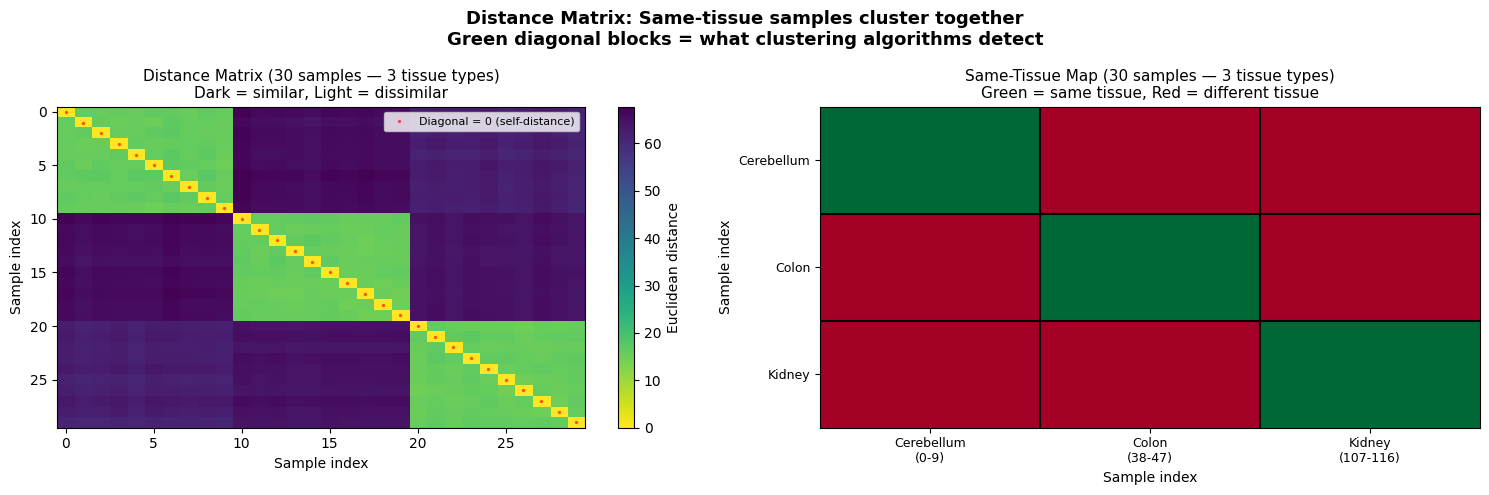

Representative pairwise distances:
------------------------------------------------------------
  Cerebellum[0] ↔ Cerebellum[1]  : 16.02  (same tissue)
  Colon[0]      ↔ Colon[1]       : 15.95  (same tissue)
  Kidney[0]     ↔ Kidney[1]      : 16.28  (same tissue)
  Cerebellum[0] ↔ Colon[0]       : 67.50  (different tissue)
  Cerebellum[0] ↔ Kidney[0]      : 62.35  (different tissue)
  Colon[0]      ↔ Kidney[0]      : 64.64  (different tissue)
------------------------------------------------------------
→ Within-tissue distances are much smaller than between-tissue distances.
  The green diagonal blocks are exactly what clustering algorithms detect
  and group together — without ever seeing the tissue labels.


In [ ]:
# @title
# ── Visualize the distance matrix ──────────────────────────────────────────────
# Right panel: 30 samples spanning 3 tissue types so the block structure shows

# Select 10 samples from each of 3 tissues
# cerebellum (indices 0-37), colon (38-71), kidney (107-145)
idx_show     = list(range(10)) + list(range(38, 48)) + list(range(107, 117))
n_show       = len(idx_show)    # 30 samples, 3 tissues
dist_slice   = dist_matrix[np.ix_(idx_show, idx_show)]
tissue_slice = tissue[idx_show]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: raw distance matrix slice ──────────────────────────────────────────
im = axes[0].imshow(dist_slice, cmap='viridis_r', aspect='auto')
axes[0].set_title(f'Distance Matrix (30 samples — 3 tissue types)\n'
                   'Dark = similar, Light = dissimilar', fontsize=11)
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('Sample index')
plt.colorbar(im, ax=axes[0], label='Euclidean distance')

axes[0].plot(range(n_show), range(n_show), 'r.', markersize=3, alpha=0.5,
             label='Diagonal = 0 (self-distance)')
axes[0].legend(fontsize=8)

# ── Right: same-tissue map ────────────────────────────────────────────────────
same_tissue = np.zeros((n_show, n_show))
for i in range(n_show):
    for j in range(n_show):
        same_tissue[i, j] = 1 if tissue_slice[i] == tissue_slice[j] else 0

axes[1].imshow(same_tissue, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
axes[1].set_title('Same-Tissue Map (30 samples — 3 tissue types)\n'
                   'Green = same tissue, Red = different tissue', fontsize=11)
axes[1].set_xlabel('Sample index')
axes[1].set_ylabel('Sample index')

# Draw tissue boundary lines at 10 and 20
for b in [10, 20]:
    axes[1].axhline(b - 0.5, color='black', linewidth=1.5)
    axes[1].axvline(b - 0.5, color='black', linewidth=1.5)

# Label tissue blocks on x-axis
axes[1].set_xticks([4.5, 14.5, 24.5])
axes[1].set_xticklabels(['Cerebellum\n(0-9)', 'Colon\n(38-47)', 'Kidney\n(107-116)'],
                          fontsize=9)
axes[1].set_yticks([4.5, 14.5, 24.5])
axes[1].set_yticklabels(['Cerebellum', 'Colon', 'Kidney'], fontsize=9)

plt.suptitle('Distance Matrix: Same-tissue samples cluster together\n'
             'Green diagonal blocks = what clustering algorithms detect',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Print representative distances using the slice indices ────────────────────
print("Representative pairwise distances:")
print("-" * 60)

# Within cerebellum (slice positions 0 and 1)
print(f"  Cerebellum[0] ↔ Cerebellum[1]  : {dist_slice[0, 1]:.2f}  (same tissue)")

# Within colon (slice positions 10 and 11)
print(f"  Colon[0]      ↔ Colon[1]       : {dist_slice[10, 11]:.2f}  (same tissue)")

# Within kidney (slice positions 20 and 21)
print(f"  Kidney[0]     ↔ Kidney[1]      : {dist_slice[20, 21]:.2f}  (same tissue)")

# Cerebellum vs colon (positions 0 and 10)
print(f"  Cerebellum[0] ↔ Colon[0]       : {dist_slice[0, 10]:.2f}  (different tissue)")

# Cerebellum vs kidney (positions 0 and 20)
print(f"  Cerebellum[0] ↔ Kidney[0]      : {dist_slice[0, 20]:.2f}  (different tissue)")

# Colon vs kidney (positions 10 and 20)
print(f"  Colon[0]      ↔ Kidney[0]      : {dist_slice[10, 20]:.2f}  (different tissue)")

print("-" * 60)
print("→ Within-tissue distances are much smaller than between-tissue distances.")
print("  The green diagonal blocks are exactly what clustering algorithms detect")
print("  and group together — without ever seeing the tissue labels.")

---

## 5. Hierarchical Clustering

### 5.1 How it works

Hierarchical clustering works **bottom-up** (agglomerative):

1. Start: each sample is its own cluster
2. Merge the two **most similar** clusters
3. Repeat until one cluster remains

The result is a **dendrogram** — a tree where the height of each merge encodes how far apart the two groups were when they joined.

**Linkage methods** define "distance between groups":
| Method | Distance between clusters A and B |
|--------|-----------------------------------|
| `complete` | max distance between any pair |
| `average` | mean distance between all pairs |
| `single` | min distance between any pair |
| `ward` | minimizes within-cluster variance |

### 5.2 Basic Dendrogram

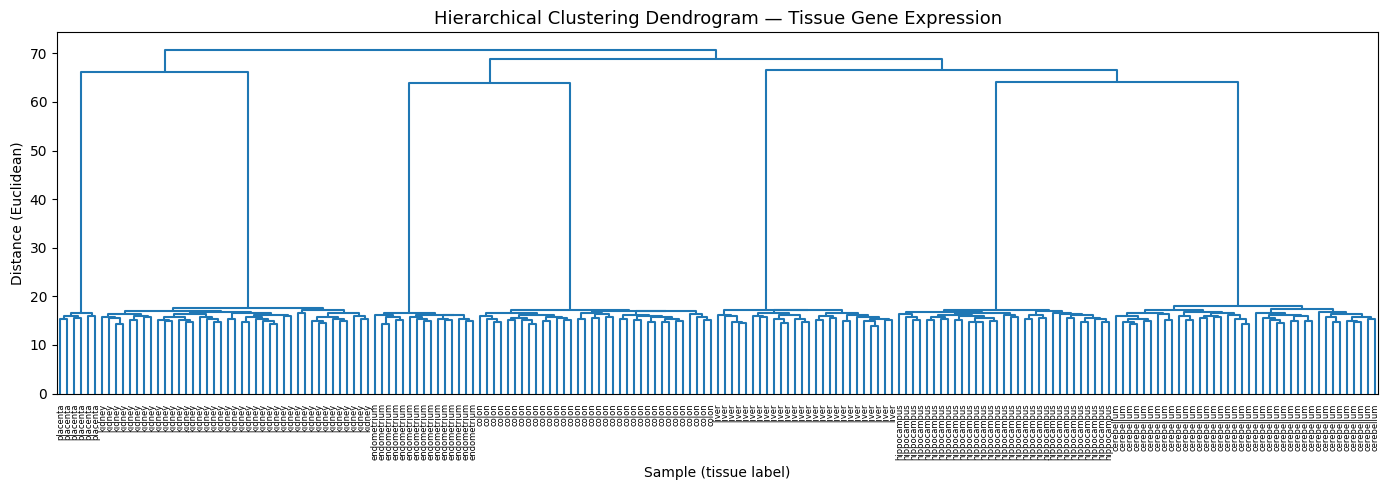

In [ ]:
# Build the linkage matrix (complete linkage, matching R's hclust default)
Z = linkage(dist_condensed, method='complete')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z,
    labels=tissue,
    leaf_rotation=90,
    leaf_font_size=6,
    ax=ax,
    color_threshold=0   # all black — we will add color in the next step
)
ax.set_title('Hierarchical Clustering Dendrogram — Tissue Gene Expression', fontsize=13)
ax.set_xlabel('Sample (tissue label)', fontsize=10)
ax.set_ylabel('Distance (Euclidean)', fontsize=10)
plt.tight_layout()
plt.show()

### 5.3 Color-coded Dendrogram

Adding tissue-type colors to the leaves makes it much easier to see whether the algorithm has "discovered" biologically meaningful groups — without having told the algorithm about the tissue labels.

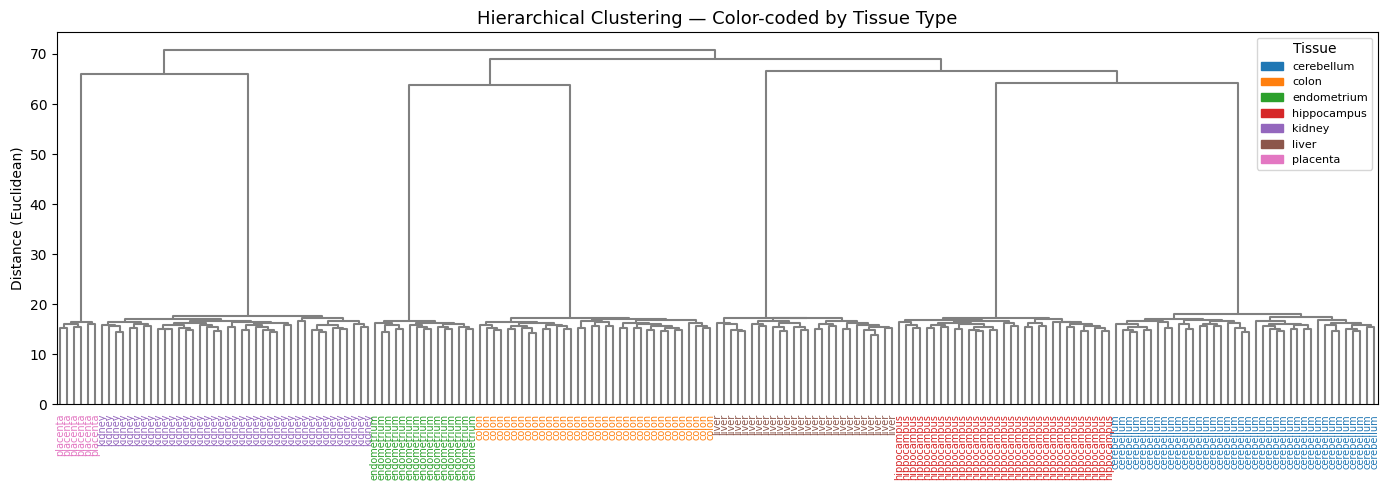

In [ ]:
# Assign a consistent color to each tissue type
palette = plt.get_cmap('tab10').colors
tissue_to_color = {t: palette[i] for i, t in enumerate(tissue_names)}
leaf_colors = [tissue_to_color[t] for t in tissue]

fig, ax = plt.subplots(figsize=(14, 5))
ddata = dendrogram(
    Z,
    labels=tissue,
    leaf_rotation=90,
    leaf_font_size=7,
    ax=ax,
    color_threshold=0,
    above_threshold_color='grey',
    no_plot=False
)

# Color the x-tick labels by tissue type
xlabels = ax.get_xmajorticklabels()
for lbl in xlabels:
    lbl.set_color(tissue_to_color.get(lbl.get_text(), 'black'))

# Legend
legend_patches = [mpatches.Patch(color=tissue_to_color[t], label=t) for t in tissue_names]
ax.legend(handles=legend_patches, fontsize=8, loc='upper right', title='Tissue')

ax.set_title('Hierarchical Clustering — Color-coded by Tissue Type', fontsize=13)
ax.set_ylabel('Distance (Euclidean)', fontsize=10)
plt.tight_layout()
plt.show()

**Observation:** Even though the algorithm received no tissue labels, leaves of the same color tend to cluster together — strong evidence that gene expression profiles carry tissue-type information.

---

### 5.4 Cutting the Tree to Define Clusters

A dendrogram does not define clusters by itself. We must **"cut"** the tree at a chosen height. All samples connected *below* the cut line form a single cluster.

We draw a horizontal line at height = 10 as an example:

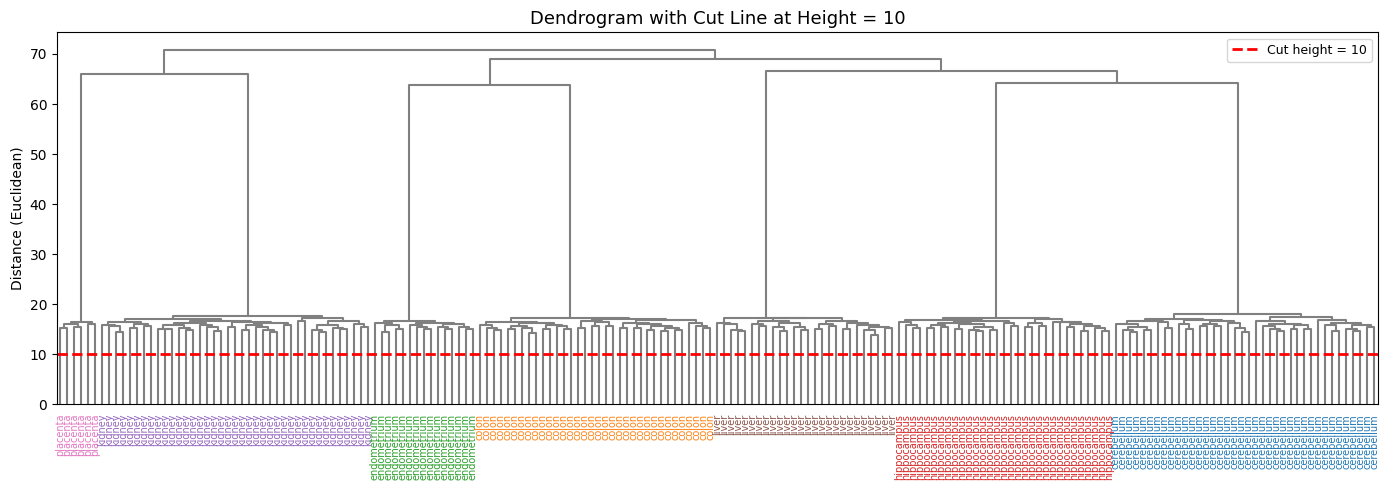

In [ ]:
CUT_HEIGHT = 10

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z,
    labels=tissue,
    leaf_rotation=90,
    leaf_font_size=7,
    ax=ax,
    color_threshold=0,
    above_threshold_color='grey'
)
xlabels = ax.get_xmajorticklabels()
for lbl in xlabels:
    lbl.set_color(tissue_to_color.get(lbl.get_text(), 'black'))

# Horizontal cut line
ax.axhline(y=CUT_HEIGHT, color='red', linewidth=2, linestyle='--',
           label=f'Cut height = {CUT_HEIGHT}')
ax.legend(fontsize=9, loc='upper right')
ax.set_title(f'Dendrogram with Cut Line at Height = {CUT_HEIGHT}', fontsize=13)
ax.set_ylabel('Distance (Euclidean)', fontsize=10)
plt.tight_layout()
plt.show()

### 5.5 Evaluating Cluster Assignments

We can cut by height **or** by specifying the desired number of clusters $k$. We compare the resulting cluster assignments against the true tissue labels using a **contingency table**.

In [ ]:
# ── Cut by height ─────────────────────────────────────────────────────────────
hclusters_h = fcluster(Z, t=CUT_HEIGHT, criterion='distance')
ct_height = pd.crosstab(tissue, hclusters_h,
                         rownames=['True tissue'], colnames=['Cluster (h=10)'])
print("=== Contingency table — cut by height ===")
print(ct_height)

print()

# ── Cut by k = 7 clusters ─────────────────────────────────────────────────────
hclusters_k = fcluster(Z, t=7, criterion='maxclust')
ct_k = pd.crosstab(tissue, hclusters_k,
                    rownames=['True tissue'], colnames=['Cluster (k=7)'])
print("=== Contingency table — cut by k = 7 ===")
print(ct_k)

=== Contingency table — cut by height ===
Cluster (h=10)  1    2    3    4    5    6    7    8    9    10   ...  180  \
True tissue                                                       ...        
cerebellum        0    0    0    0    0    0    0    0    0    0  ...    1   
colon             0    0    0    0    0    0    0    0    0    0  ...    0   
endometrium       0    0    0    0    0    0    0    0    0    0  ...    0   
hippocampus       0    0    0    0    0    0    0    0    0    0  ...    0   
kidney            0    0    0    0    0    0    1    1    1    1  ...    0   
liver             0    0    0    0    0    0    0    0    0    0  ...    0   
placenta          1    1    1    1    1    1    0    0    0    0  ...    0   

Cluster (h=10)  181  182  183  184  185  186  187  188  189  
True tissue                                                  
cerebellum        1    1    1    1    1    1    1    1    1  
colon             0    0    0    0    0    0    0    0    0  
endomet

**Interpretation:** Each row is a true tissue type; each column is a discovered cluster. A good clustering would show one dominant entry per row (one tissue → one cluster). Spread across columns suggests the chosen $k$ may be too high or too low.

---

## 6. K-Means Clustering

### 6.1 How it works

K-means partitions $n$ samples into exactly $k$ clusters by minimizing the **within-cluster sum of squares**:

$$\underset{C_1, \ldots, C_k}{\min} \sum_{j=1}^{k} \sum_{\mathbf{x} \in C_j} \|\mathbf{x} - \boldsymbol{\mu}_j\|^2$$

where $\boldsymbol{\mu}_j$ is the **centroid** (mean) of cluster $j$. The algorithm alternates between:
1. **Assignment step** — assign each sample to the nearest centroid
2. **Update step** — recalculate centroids

### 6.2 K-Means on the First Two Genes Only

We first illustrate how poorly k-means performs when we use only the first two genes — likely uninformative for distinguishing tissues.

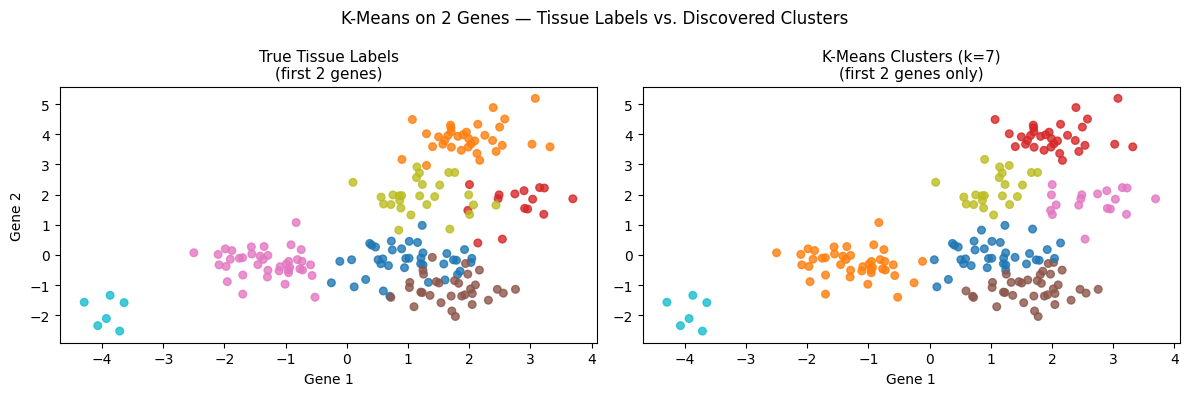


Contingency table — K-means (2 genes):
K-means cluster   0   1   2   3   4   5  6
True tissue                               
cerebellum       29   2   0   7   0   0  0
colon             0   0  32   0   0   2  0
endometrium       1   0   0   0  14   0  0
hippocampus       2   0   0  29   0   0  0
kidney            0  39   0   0   0   0  0
liver             2   0   0   0   4  20  0
placenta          0   0   0   0   0   0  6


In [ ]:
np.random.seed(1)
km2 = KMeans(n_clusters=7, n_init=10, random_state=1)
km2.fit(E[:2, :].T)   # use only first 2 genes; shape: (189, 2)

# Numeric codes for true tissue labels (for coloring)
tissue_codes = pd.Categorical(tissue, categories=tissue_names).codes

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: true tissue labels
axes[0].scatter(E[0, :], E[1, :],
                c=tissue_codes, cmap='tab10', s=30, alpha=0.8)
axes[0].set_title('True Tissue Labels\n(first 2 genes)', fontsize=11)
axes[0].set_xlabel('Gene 1'); axes[0].set_ylabel('Gene 2')

# Right: k-means clusters
axes[1].scatter(E[0, :], E[1, :],
                c=km2.labels_, cmap='tab10', s=30, alpha=0.8)
axes[1].set_title('K-Means Clusters (k=7)\n(first 2 genes only)', fontsize=11)
axes[1].set_xlabel('Gene 1')

plt.suptitle('K-Means on 2 Genes — Tissue Labels vs. Discovered Clusters', fontsize=12)
plt.tight_layout()
plt.show()

print("\nContingency table — K-means (2 genes):")
print(pd.crosstab(tissue, km2.labels_,
                   rownames=['True tissue'], colnames=['K-means cluster']))

**Result:** Using only 2 genes, k-means does *not* recover the tissue structure well. The genes are not discriminative on their own.

### 6.3 K-Means on All Genes + MDS Visualization

When we use all 500 genes, the tissue structure becomes apparent. Because we cannot plot 500 dimensions directly, we use **MDS (Multidimensional Scaling)** to project samples into 2D while preserving pairwise distances.

## 📌 Multidimensional Scaling (MDS): Concepts and Intuition

---

### What is MDS?

MDS takes a table of **pairwise distances** between objects and finds coordinates
for each object in a low-dimensional space (usually 2D) so that:

- Objects that are **far apart** in the original data appear **far apart** on the map
- Objects that are **close** in the original data appear **close** on the map

---

### The Map Analogy — Start Here

Imagine you have a table of driving distances between 5 US cities — but **no map**:

|          | NYC   | Boston | Chicago | Dallas | LA    |
|----------|-------|--------|---------|--------|-------|
| NYC      | 0     | 215    | 790     | 1,550  | 2,800 |
| Boston   | 215   | 0      | 980     | 1,750  | 3,000 |
| Chicago  | 790   | 980    | 0       | 920    | 2,020 |
| Dallas   | 1,550 | 1,750  | 920     | 0      | 1,430 |
| LA       | 2,800 | 3,000  | 2,020   | 1,430  | 0     |

MDS asks: **can I place 5 dots on a 2D plane so that the distances between
the dots match this table as closely as possible?**

The answer is yes — and the result looks almost exactly like a map of the
United States. You gave it **no coordinates**. It recovered geography
purely from distances.

---



Input: Pairwise Distance Matrix (miles)
---------------------------------------------
                 NYC    Boston   Chicago    Dallas        LA
       NYC         0       215       790      1550      2800
    Boston       215         0       980      1750      3000
   Chicago       790       980         0       920      2020
    Dallas      1550      1750       920         0      1430
        LA      2800      3000      2020      1430         0

MDS Stress : 130.91
(Lower = better fit between map distances and original distances)

Recovered 2D Coordinates:
-----------------------------------
  NYC         x =   -195.1   y =   -951.9
  Boston      x =   -168.6   y =  -1161.9
  Chicago     x =    115.6   y =   -225.8
  Dallas      x =   -299.6   y =    591.8
  LA          x =    547.7   y =   1747.8


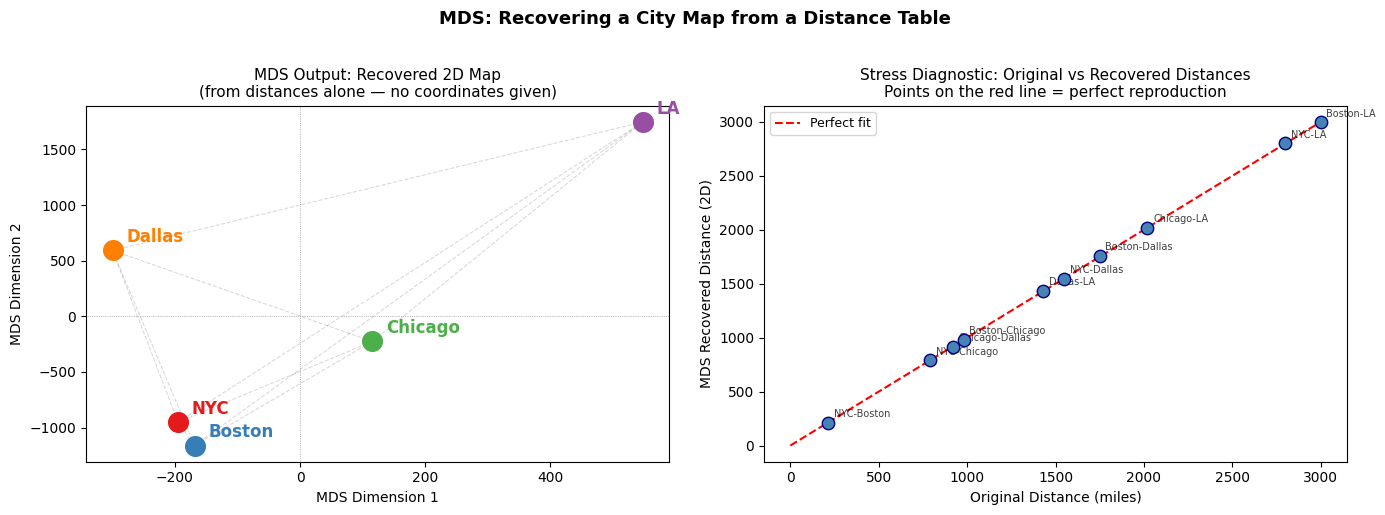


Sanity Check: Are relationships preserved?
--------------------------------------------------
  NYC        ↔ Boston     | Original:    215 mi | Recovered:    212 | Error: 1.5%
  NYC        ↔ LA         | Original:   2800 mi | Recovered:   2800 | Error: 0.0%
  Chicago    ↔ Dallas     | Original:    920 mi | Recovered:    917 | Error: 0.3%
  Dallas     ↔ LA         | Original:   1430 mi | Recovered:   1433 | Error: 0.2%


In [ ]:
# @title
# ============================================================
# MDS Demo: Recovering a City Map from Distances Alone
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS

# ── 1. Define the distance matrix (miles between cities) ─────
cities = ['NYC', 'Boston', 'Chicago', 'Dallas', 'LA']

distances = np.array([
    [    0,  215,  790, 1550, 2800],
    [  215,    0,  980, 1750, 3000],
    [  790,  980,    0,  920, 2020],
    [ 1550, 1750,  920,    0, 1430],
    [ 2800, 3000, 2020, 1430,    0]
])

print("Input: Pairwise Distance Matrix (miles)")
print("-" * 45)
header = f"{'':>10}" + "".join(f"{c:>10}" for c in cities)
print(header)
for i, city in enumerate(cities):
    row = f"{city:>10}" + "".join(f"{distances[i,j]:>10}" for j in range(len(cities)))
    print(row)

# ── 2. Run MDS ───────────────────────────────────────────────
mds = MDS(n_components=2,        # project into 2D
          dissimilarity='precomputed',  # we are giving a distance matrix
          random_state=42,
          normalized_stress=False)

coords = mds.fit_transform(distances)

print(f"\nMDS Stress : {mds.stress_:.2f}")
print(f"(Lower = better fit between map distances and original distances)\n")
print("Recovered 2D Coordinates:")
print("-" * 35)
for city, (x, y) in zip(cities, coords):
    print(f"  {city:<10}  x = {x:>8.1f}   y = {y:>8.1f}")

# ── 3. Plot the recovered map ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: MDS recovered map ──────────────────────────────────
ax = axes[0]
colors_city = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00', '#984ea3']

for i, (city, (x, y)) in enumerate(zip(cities, coords)):
    ax.scatter(x, y, s=200, color=colors_city[i], zorder=5)
    ax.annotate(city, (x, y),
                textcoords="offset points", xytext=(10, 6),
                fontsize=12, fontweight='bold', color=colors_city[i])

# Draw dashed lines between all pairs with distance labels
for i in range(len(cities)):
    for j in range(i + 1, len(cities)):
        x_vals = [coords[i, 0], coords[j, 0]]
        y_vals = [coords[i, 1], coords[j, 1]]
        ax.plot(x_vals, y_vals, 'k--', alpha=0.15, linewidth=0.8)

ax.set_title('MDS Output: Recovered 2D Map\n'
             '(from distances alone — no coordinates given)',
             fontsize=11)
ax.set_xlabel('MDS Dimension 1')
ax.set_ylabel('MDS Dimension 2')
ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
ax.axvline(0, color='gray', linewidth=0.5, linestyle=':')

# ── Right: Original vs Recovered distances (Stress plot) ─────
ax2 = axes[1]
original_dists = []
recovered_dists = []

for i in range(len(cities)):
    for j in range(i + 1, len(cities)):
        original_dists.append(distances[i, j])
        rec = np.linalg.norm(coords[i] - coords[j])
        recovered_dists.append(rec)

ax2.scatter(original_dists, recovered_dists,
            s=80, color='steelblue', edgecolors='navy', zorder=5)

# Perfect fit reference line
max_val = max(max(original_dists), max(recovered_dists))
ax2.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect fit')

# Annotate each pair
pair_labels = []
for i in range(len(cities)):
    for j in range(i + 1, len(cities)):
        pair_labels.append(f"{cities[i]}-{cities[j]}")

for label, ox, rx in zip(pair_labels, original_dists, recovered_dists):
    ax2.annotate(label, (ox, rx),
                 textcoords="offset points", xytext=(4, 4),
                 fontsize=7, alpha=0.75)

ax2.set_title('Stress Diagnostic: Original vs Recovered Distances\n'
              'Points on the red line = perfect reproduction',
              fontsize=11)
ax2.set_xlabel('Original Distance (miles)')
ax2.set_ylabel('MDS Recovered Distance (2D)')
ax2.legend(fontsize=9)

plt.suptitle('MDS: Recovering a City Map from a Distance Table',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── 4. Verify key relationships are preserved ────────────────
print("\nSanity Check: Are relationships preserved?")
print("-" * 50)
checks = [
    ("NYC", "Boston"),
    ("NYC", "LA"),
    ("Chicago", "Dallas"),
    ("Dallas", "LA"),
]
for c1, c2 in checks:
    i, j = cities.index(c1), cities.index(c2)
    orig = distances[i, j]
    rec  = np.linalg.norm(coords[i] - coords[j])
    pct_err = abs(orig - rec) / orig * 100
    print(f"  {c1:<10} ↔ {c2:<10} | "
          f"Original: {orig:>6.0f} mi | "
          f"Recovered: {rec:>6.0f} | "
          f"Error: {pct_err:.1f}%")

### Why is This Useful in Machine Learning?

Real data is high-dimensional. A gene expression dataset might have 20,000
features per sample — impossible to plot directly. But you **can** compute
how similar or dissimilar any two samples are, and MDS turns that similarity
table into a 2D picture you can actually look at.

> **Core principle:** Objects that are similar → points close together.
> Objects that are dissimilar → points far apart.

---

### Input and Output

| | Description |
|--|--|
| **Input** | An $n \times n$ distance (or dissimilarity) matrix — one entry per pair of objects |
| **Output** | $n$ points placed in 2D (or 3D) space, preserving those distances as faithfully as possible |

The dissimilarities can come from:
- Direct measurements (physical distances, response times)
- Subjective ratings ("how similar are these two things on a scale of 1–9?")
- Computed metrics (Euclidean distance, correlation, sequence alignment scores)

---

### What Does MDS Optimize? — Stress

MDS cannot always perfectly reproduce all pairwise distances in 2D — some
distortion is inevitable when squashing high-dimensional relationships onto
a flat plane. It measures how badly it is doing with a quantity called **Stress**:

$$\text{Stress} = \left(\frac{\sum_{i < j}(d_{ij} - \hat{d}_{ij})^2}{\sum_{i < j} d_{ij}^2}\right)^{1/2}$$

Where:
- $d_{ij}$ — the **original** distance between objects $i$ and $j$ (from your input table)
- $\hat{d}_{ij}$ — the **map distance** between points $i$ and $j$ in the 2D layout
- The sum runs over **all pairs** of objects ($i < j$ to avoid counting each pair twice)

MDS iteratively moves the 2D points to **minimize Stress** — making map
distances match original distances as closely as possible.

| Stress Value | Interpretation |
|---|---|
| $< 0.05$ | Excellent fit |
| $0.05 - 0.10$ | Good fit |
| $0.10 - 0.20$ | Acceptable fit |
| $> 0.20$ | Poor fit — map is misleading |

---

### MDS vs. PCA — What is the Difference?

Both reduce dimensionality, but they start from very different places:

| | PCA | MDS |
|--|-----|-----|
| **Input** | Raw data matrix ($n \times p$) | Distance matrix ($n \times n$) |
| **Goal** | Maximize variance explained | Preserve pairwise distances |
| **Needs raw features?** | Yes | No — only needs distances |
| **Focus** | The dimensions themselves | The relationships between objects |

**Key insight:** MDS is especially powerful when you **only have a similarity
matrix** — for example, survey ratings, biological sequence alignments, or
social network distances — and never had raw feature vectors to begin with.

---

### Metric vs. Non-Metric MDS

| Type | What it Preserves | Use When |
|------|-------------------|----------|
| **Metric MDS** | Actual distance magnitudes | Data is quantitative (e.g., Euclidean distances) |
| **Non-Metric MDS** | Only the **rank order** of distances | Data is ordinal (e.g., survey ratings) |

In non-metric MDS, what matters is: if objects $A$ and $B$ are closer than
$C$ and $D$ in the original data, they should also be closer on the map —
but the exact numerical distances do not need to match.

---

### Where is MDS Used?

- **Bioinformatics** — visualizing similarity across gene expression profiles or DNA sequences
- **Psychology** — mapping how people perceive similarity between colors, sounds, or concepts
- **Marketing** — placing competing brands on a perceptual map from customer similarity ratings
- **NLP** — visualizing semantic similarity between documents or words

---

### The One-Line Summary

> MDS is a **map-maker**. Give it a table of *"how far apart are these things?"*
> and it draws you a picture where distances on the page match distances in
> your data — as faithfully as a 2D plane allows.

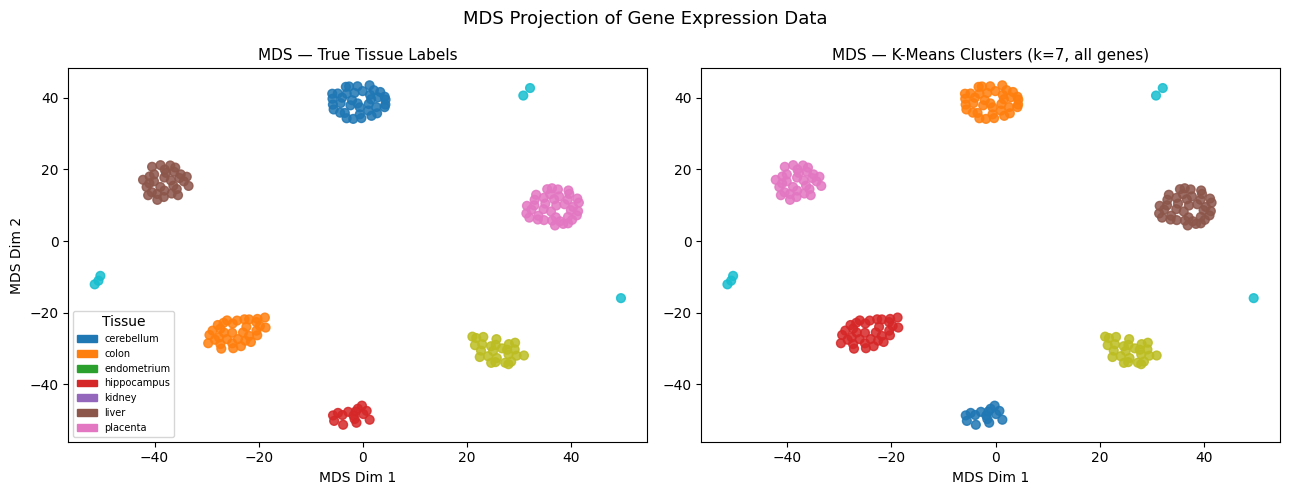


Contingency table — K-means (all genes):
K-means cluster   0   1   2   3   4   5  6
True tissue                               
cerebellum        0  38   0   0   0   0  0
colon             0   0  34   0   0   0  0
endometrium      15   0   0   0   0   0  0
hippocampus       0   0   0   0  31   0  0
kidney            0   0   0  39   0   0  0
liver             0   0   0   0   0  26  0
placenta          0   0   0   0   0   0  6


In [ ]:
np.random.seed(1)

# ── K-Means on all 500 genes ───────────────────────────────────────────────────
km_all = KMeans(n_clusters=7, n_init=10, random_state=1)
km_all.fit(E.T)   # shape: (189, 500)

# ── MDS projection ─────────────────────────────────────────────────────────────
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, n_init=4)
mds_coords = mds.fit_transform(dist_matrix)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: colored by true tissue
sc1 = axes[0].scatter(mds_coords[:, 0], mds_coords[:, 1],
                       c=tissue_codes, cmap='tab10', s=40, alpha=0.85)
legend_patches = [mpatches.Patch(color=palette[i], label=t)
                  for i, t in enumerate(tissue_names)]
axes[0].legend(handles=legend_patches, fontsize=7, title='Tissue')
axes[0].set_title('MDS — True Tissue Labels', fontsize=11)
axes[0].set_xlabel('MDS Dim 1'); axes[0].set_ylabel('MDS Dim 2')

# Right: colored by k-means clusters (all genes)
axes[1].scatter(mds_coords[:, 0], mds_coords[:, 1],
                c=km_all.labels_, cmap='tab10', s=40, alpha=0.85)
axes[1].set_title('MDS — K-Means Clusters (k=7, all genes)', fontsize=11)
axes[1].set_xlabel('MDS Dim 1')

plt.suptitle('MDS Projection of Gene Expression Data', fontsize=13)
plt.tight_layout()
plt.show()

print("\nContingency table — K-means (all genes):")
print(pd.crosstab(tissue, km_all.labels_,
                   rownames=['True tissue'], colnames=['K-means cluster']))

**Key takeaway:** With all genes, k-means produces clusters that closely mirror the true tissue structure — comparable to the result from hierarchical clustering.

---

## 7. Heatmaps

Heatmaps are **ubiquitous in genomics**. They simultaneously show:
- Gene expression levels across all samples (color intensity)
- Hierarchical clustering of both genes and samples (dendrograms on axes)
- Tissue-type annotations (colored bar on top)

### 7.1 Select the Most Variable Genes

Showing all 500 genes is noisy. We pick the **top 40 genes by variance** — these are most likely to distinguish tissue types.

In [ ]:
# Variance across samples for each gene
gene_var = np.var(E, axis=1)
top40_idx = np.argsort(-gene_var)[:40]   # descending order, keep top 40

E_top40 = E[top40_idx, :]   # shape: (40, 189)

print(f"Selected {E_top40.shape[0]} most variable genes out of {E.shape[0]} total")
print(f"Variance range of selected genes: {gene_var[top40_idx].min():.3f} – {gene_var[top40_idx].max():.3f}")

Selected 40 most variable genes out of 500 total
Variance range of selected genes: 6.724 – 14.937


### 7.2 How to Read a Clustered Heatmap

A clustered heatmap has five visual components, arranged as shown below:

**Top:** Column dendrogram — a tree showing how samples were clustered.
Samples that are similar in gene expression are placed next to each other.

**Below the top tree:** Tissue color bar — a colored strip annotating
each sample's tissue type. This lets you check whether the clustering
discovered the tissue groups without being told the labels.

**Left side:** Row dendrogram — a tree showing how genes were clustered.
Genes that go up and down together across samples are placed next to each other.
These are called co-expressed genes.

**Center:** The heatmap body — a grid where each cell shows the expression
level of one gene (row) in one sample (column). Color intensity encodes
expression: dark = high, light = low.

**Right side:** Color scale bar — maps colors to expression values.

---

A simple way to remember the layout:

- Rows = genes (what is being measured)
- Columns = samples (who was measured)
- Color = how much (expression level)
- Dendrograms on both sides = who clusters with whom

---

#### What is on each axis?

| Axis | What it shows | After clustering |
|------|--------------|-----------------|
| **X-axis (columns)** | Individual **samples** (189 tissue samples) | Reordered so similar samples are adjacent |
| **Y-axis (rows)** | Individual **genes** (top 40 most variable) | Reordered so co-expressed genes are adjacent |

**Key point:** The original order of samples and genes is discarded.
The clustering algorithm reorders both axes so that similar things sit next to
each other — making patterns visible as rectangular blocks of color.

---

#### What does the color mean?

Each cell at position (gene, sample) shows the **expression level** of that gene
in that sample, after row-normalization (explained below):

| Color (GnBu palette) | Meaning |
|---------------------|---------|
| Dark blue | High expression — this gene is very active in this sample |
| Light blue / white | Low expression — this gene is quiet in this sample |

---

#### What does `standard_scale=0` (row normalization) do?

Without normalization, genes with naturally high expression levels would dominate
the color scale, drowning out genes with lower but equally informative variation.

`standard_scale=0` **scales each gene (row) independently** to the range [0, 1]:

$$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

After scaling:
- The **least expressed sample** for each gene gets value 0 (white)
- The **most expressed sample** for each gene gets value 1 (dark blue)

This lets you compare **patterns** across genes on a common scale, regardless
of their absolute expression levels.

> ⚠️ This means you **cannot** compare absolute values between rows —
> only the relative pattern within each row is meaningful.

---

#### The two dendrograms — what are they clustering?

**Column dendrogram (top) — clustering samples:**
- Each leaf is one tissue sample
- Two samples are merged when their gene expression profiles are similar
- The height of a merge = how different the two groups were when joined
- Read it like: "these samples look biologically alike"

**Row dendrogram (left) — clustering genes:**
- Each leaf is one gene
- Two genes are merged when they have similar expression patterns across all samples
- Genes that appear close together are **co-expressed** — they go up and down together
- In biology, co-expressed genes often share a function or regulatory pathway

---

#### How to read the heatmap in practice

Start with the **column dendrogram** (top):
1. Find the largest branches — these are the major sample groups
2. Check the **tissue color bar** below it — do same-colored samples cluster together?
3. If yes: the algorithm discovered tissue types without being told the labels ✓

Then look at the **body of the heatmap**:
4. Find rectangular blocks of dark blue — a gene that is highly expressed in one tissue group
5. Find rectangular blocks of white — the same gene is quiet in other tissues
6. These tissue-specific blocks are called **expression signatures** or **marker genes**

Finally look at the **row dendrogram** (left):
7. Genes that cluster together near the top have similar expression patterns
8. These gene groups may share biological function (e.g., all metabolic genes,
   all immune genes, etc.)

### 7.2 Build the Heatmap

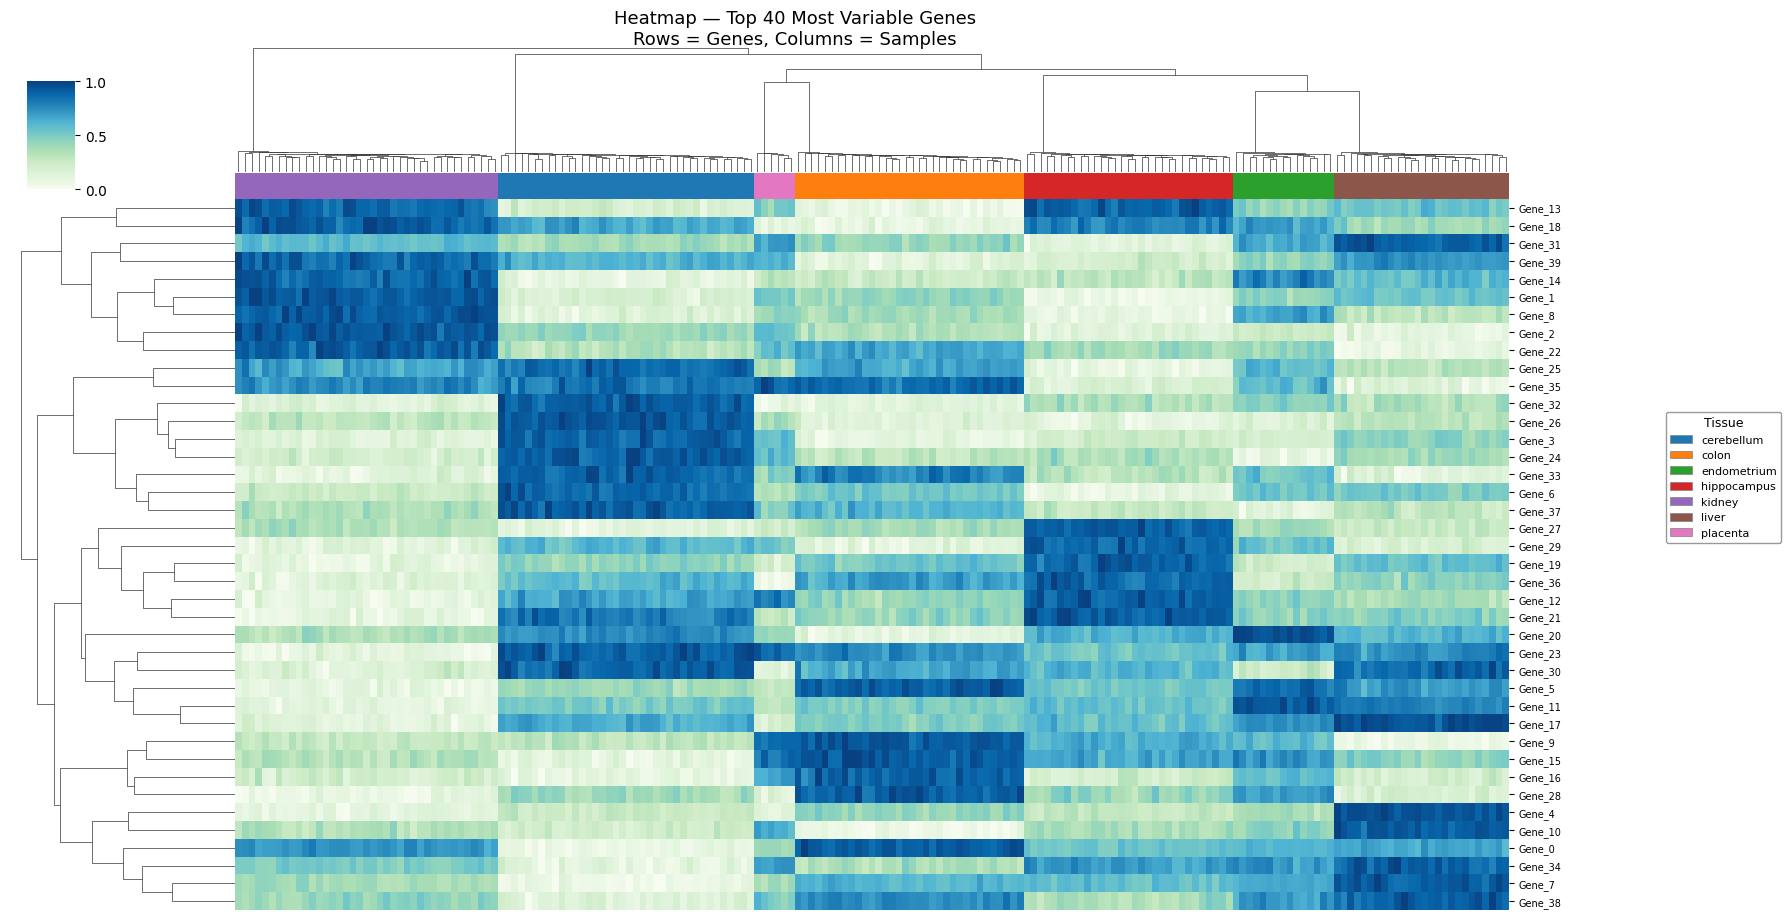


Note: Tissue labels are NOT used by the clustering algorithm —
the separation emerges purely from gene expression patterns.


In [ ]:
# @title
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

# ── Column annotation colors (one color per tissue) ───────────────────────────
# Convert tab10 RGB tuples to hex — seaborn needs hex, not tuples
palette_hex = [mcolors.to_hex(palette[i]) for i in range(len(tissue_names))]
tissue_color_map = {t: palette_hex[i] for i, t in enumerate(tissue_names)}

# KEY: pass col_colors as a plain list aligned to columns, not a pandas Series
# A pandas Series with string tissue labels as index can confuse seaborn's
# internal alignment — a list is unambiguous
col_colors_list = [tissue_color_map[t] for t in tissue]

# ── Build a DataFrame for seaborn clustermap ──────────────────────────────────
df_heatmap = pd.DataFrame(
    E_top40,
    index=[f'Gene_{i}' for i in range(40)],
    columns=range(189)    # integer columns avoid duplicate-label alignment issues
)

# ── Draw clustermap ───────────────────────────────────────────────────────────
g = sns.clustermap(
    df_heatmap,
    col_colors=col_colors_list,   # plain list — one hex color per sample column
    cmap='GnBu',
    standard_scale=0,             # scale each gene (row) to [0, 1]
    figsize=(16, 9),
    xticklabels=False,            # 189 sample labels are too dense to read
    yticklabels=True,
    dendrogram_ratio=(0.15, 0.15),
    cbar_pos=(0.02, 0.82, 0.03, 0.12)
)

# ── Label sizes ───────────────────────────────────────────────────────────────
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=7)

# ── Tissue legend — placed on the figure, not on an axis ─────────────────────
legend_handles = [
    mpatches.Patch(facecolor=tissue_color_map[t], edgecolor='grey',
                   linewidth=0.5, label=t)
    for t in tissue_names
]
g.fig.legend(
    handles=legend_handles,
    title='Tissue', title_fontsize=9, fontsize=8,
    loc='center right', bbox_to_anchor=(1.12, 0.5),
    frameon=True, edgecolor='grey'
)

# ── Title ─────────────────────────────────────────────────────────────────────
g.fig.suptitle(
    'Heatmap — Top 40 Most Variable Genes\nRows = Genes, Columns = Samples',
    y=1.02, fontsize=13
)
plt.show()
print("\nNote: Tissue labels are NOT used by the clustering algorithm —")
print("the separation emerges purely from gene expression patterns.")

> **Key result — but with an important caveat:**
>
> In this notebook the data was **synthetically generated** — we deliberately
> built each tissue's expression profile to be distinct (between-tissue spread = 2,
> within-tissue noise = 0.5). So the clean separation you see in the heatmap
> is expected by design, not a discovery.
>
> **In real biology, this is what you hope to find.** When you run hierarchical
> clustering on actual RNA-seq or microarray data without providing tissue labels,
> and the resulting heatmap shows samples of the same tissue type clustering
> together, that is a genuine scientific result. It tells you that:
>
> - The gene expression signal is strong enough to distinguish tissue types
> - The 40 most variable genes carry biologically meaningful information
> - The distance measure and clustering method are appropriate for this data
>
> The synthetic data here is designed to give you the intuition and the
> mechanics. The real payoff comes when you apply the same pipeline to
> data where the answer is not known in advance — and the clusters still
> make biological sense.

---

## 7.3 How the Heatmap is Built — Two Clusterings, One Picture

The heatmap is not a single analysis. It is the result of running
**two completely independent hierarchical clusterings** and then bringing
them together in one visualization. Understanding this is the key to
reading any clustered heatmap in genomics.

---

### Step 1 — Cluster the Samples (columns) using $E^T$

```python
pdist(E.T)   # E.T shape: (189 samples × 500 genes)
```

- Each **row** of $E^T$ is one sample — its expression profile across 500 genes
- `pdist(E.T)` computes a **189 × 189 distance matrix** — one entry per pair of samples
- Hierarchical clustering runs on this matrix
- The result is a **dendrogram that goes on the top** of the heatmap
- Columns are **reordered** so that similar samples sit next to each other

Two samples are close if their gene expression profiles look alike.
Cerebellum samples end up next to other cerebellum samples — not because
we told the algorithm the tissue labels, but because their 500-gene
profiles are numerically similar.

---

### Step 2 — Cluster the Genes (rows) using $E$

```python
pdist(E)   # E shape: (500 genes × 189 samples)
```

- Each **row** of $E$ is one gene — its expression level across 189 samples
- `pdist(E)` computes a **500 × 500 distance matrix** — one entry per pair of genes
- Hierarchical clustering runs on this matrix
- The result is a **dendrogram that goes on the left** of the heatmap
- Rows are **reordered** so that co-expressed genes sit next to each other

Two genes are close if they go up and down together across all 189 samples.
Genes that are both high in cerebellum and low in liver will cluster together —
these are called **co-expressed genes** and often share biological function
or regulatory pathway.

---

### Step 3 — Bring Them Together

Once both clusterings are done, `seaborn.clustermap` assembles the picture:

```
Original matrix E (500 × 189)
        ↓
Reorder columns by sample dendrogram leaf order
        ↓
Reorder rows by gene dendrogram leaf order
        ↓
Draw the heatmap body with both dendrograms attached
```

---

### The Two Clusterings at a Glance

| | Sample clustering | Gene clustering |
|--|-------------------|-----------------|
| Input | $E^T$ — (189 × 500) | $E$ — (500 × 189) |
| Distance matrix | 189 × 189 | 500 × 500 |
| One entry = | similarity between two samples | similarity between two genes |
| Dendrogram position | Top of heatmap | Left of heatmap |
| Reorders | Columns | Rows |
| "Close" means | Similar expression profiles | Similar expression patterns across samples |

---

### What Emerges

After both reorderings, **rectangular blocks of color** appear in the heatmap body.
A dark block at the intersection of a gene group (rows) and a sample group (columns)
means those genes are highly expressed specifically in those samples.

This is a **tissue-specific expression signature** — and it appears purely from
the distance structure of the data, with no tissue labels ever given to either
clustering algorithm.

**Observation:** With just 40 highly variable genes, the heatmap shows clear separation among the tissue types — matching the result in the original R tutorial.

---

## 8. Summary

| Method | Type | Key parameter | Python function |
|--------|------|---------------|-----------------|
| Hierarchical clustering | Unsupervised | linkage method | `scipy.cluster.hierarchy.linkage` |
| Tree cutting (by height) | Unsupervised | cut height $h$ | `fcluster(..., criterion='distance')` |
| Tree cutting (by $k$) | Unsupervised | num clusters $k$ | `fcluster(..., criterion='maxclust')` |
| K-Means | Unsupervised | num clusters $k$ | `sklearn.cluster.KMeans` |
| MDS | Dimensionality reduction | num components | `sklearn.manifold.MDS` |
| Clustermap / Heatmap | Visualization | top-variance genes | `seaborn.clustermap` |

**Key takeaways:**
- Feature selection matters: 2 genes vs. 500 genes produces very different k-means results
- Hierarchical clustering and k-means yield similar results when features are informative
- Choosing the number of clusters $k$ is an open research challenge (covered in Ch. 20)
- Heatmaps + dendrograms are the standard visualization in genomics

---

## 9. Exercises

1. **Linkage sensitivity:** Re-run hierarchical clustering using `method='ward'` and `method='single'`. How do the dendrograms differ from `'complete'`? Which recovers tissue structure best?

2. **Elbow method:** For k-means on all genes, plot the within-cluster sum of squares (WCSS, stored in `km.inertia_`) for $k = 2, 3, \ldots, 12$. Where is the "elbow"?

3. **Top $N$ genes:** Repeat the heatmap with the top 20 and top 100 most variable genes. How does separation quality change?

4. **Correlation distance:** Replace Euclidean distance with `1 - Pearson correlation` (`pdist(E.T, metric='correlation')`). Does hierarchical clustering improve?

5. **Bioinformatics connection:** If these were real RNA-seq samples from a patient cohort (e.g., tumor vs. normal colon tissue), what biological conclusions might you draw from a heatmap showing two well-separated clusters?

---

